<a href="https://colab.research.google.com/github/edaska/Stochastic_Processes_-_Optimization_in_Machine_Learning/blob/main/lab11/Stochastics_Random_Forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!--BOOK_INFORMATION-->
<img align="left" style="padding-right:10px;" src="https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/figures/PDSH-cover-small.png?raw=1">

*This notebook contains an excerpt from the [Python Data Science Handbook](http://shop.oreilly.com/product/0636920034919.do) by Jake VanderPlas; the content is available [on GitHub](https://github.com/jakevdp/PythonDataScienceHandbook).*

*The text is released under the [CC-BY-NC-ND license](https://creativecommons.org/licenses/by-nc-nd/3.0/us/legalcode), and code is released under the [MIT license](https://opensource.org/licenses/MIT). If you find this content useful, please consider supporting the work by [buying the book](http://shop.oreilly.com/product/0636920034919.do)!*

<br>
<strong>For the lab session of the course "<i>Stochastic Processes & Optimization in Machine Learning</i>", we have adapted the text and code from the book referenced above to better suit the needs of this course.</strong>

# Decision Trees and Random Forests

Random Forests are an example of an ensemble learning method based on decision trees.

Decision trees provide a highly intuitive way to classify or label objects: you simply ask a sequence of questions designed to lead to the final classification. For example, if you wanted to build a decision tree to classify an animal you encounter while walking, you could create one like the example shown below:

![alt text](https://jakevdp.github.io/PythonDataScienceHandbook/figures/05.08-decision-tree.png)

Binary splitting is highly efficient. In a well-constructed decision tree, each question divides the available options into two smaller groups, often reducing the number of possible choices by approximately half. This allows the model to narrow down the final decision quickly, even when there are many possible classes.

However, the main challenge in this approach is deciding which question should be asked at each step. In machine learning, decision trees usually make these decisions by splitting the data based on the values of its features. More specifically, each internal node of the tree applies a threshold to one feature and separates the data into two branches.

This process is called binary splitting because each split creates two groups. It should not be confused with binary classification: binary splitting refers to the structure of the tree, while binary classification refers to a task where there are only two possible output classes.

# Creating a Decision Tree

Suppose we have the following two-dimensional dataset, where each data point belongs to one of four classes:

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

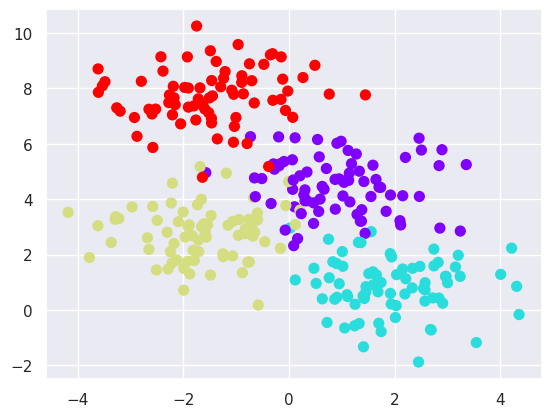

In [2]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=1.0)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow');

A simple decision tree based on this dataset will repeatedly split the data along one of the two axes, using a specific quantitative criterion to decide each split. At each level, the newly created region is assigned the label of the majority class among the points it contains.

The figure below shows the first four levels of a decision tree classifier trained on the dataset above:

![alt text](https://jakevdp.github.io/PythonDataScienceHandbook/figures/05.08-decision-tree-levels.png)


We can observe that, after the first split, all points in the upper branch belong to the same class. Therefore, this branch does not need to be split any further.

Except for nodes that already contain points from a single class, each region is split again at every level using one of the two features.


This process of fitting a decision tree to our data can be implemented in Scikit-Learn using the `DecisionTreeClassifier` estimator:

In [3]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier().fit(X, y)

The following utility function is used to visualize the output of the classifier:

In [4]:
def visualize_classifier(model, X, y, ax=None, cmap='rainbow'):
    ax = ax or plt.gca()

    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=cmap,
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # fit the estimator
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Create a color plot with the results
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap=cmap, clim=(y.min(), y.max()),
                           zorder=1)

    ax.set(xlim=xlim, ylim=ylim)

/tmp/ipykernel_597/1795456885.py:20: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,


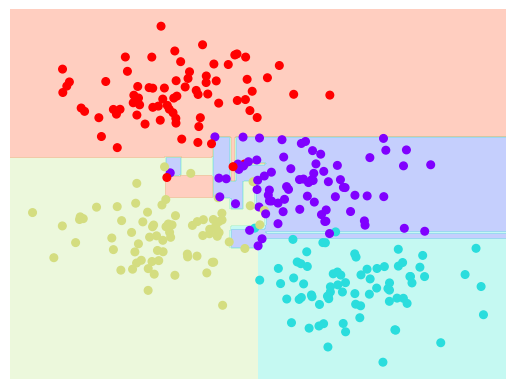

In [5]:
visualize_classifier(DecisionTreeClassifier(), X, y)

The following is an interactive visualization of the decision tree construction process:

![alt text](...%0ASUVORK5CYII=)

As the depth of the tree increases, the classification regions become more irregular and complex. For example, at depth five, a small purple region appears between the yellow and blue regions. This region is unlikely to represent the true underlying structure of the data. Instead, it is probably caused by sampling variation or noise in the dataset.

In the code above, the <i>Gini Index</i> was used as the criterion for choosing which feature to split on at each node of the Decision Tree.

<ul>
<li><b>Question 1:</b> Describe how a Decision Tree is constructed using the Gini Index.</li>
</ul>

Another commonly used criterion for constructing Decision Trees is <i>Entropy</i>.

<ul>
<li><b>Question 2:</b> Explain the differences between the Gini Index and the Entropy criterion.</li>
<li><b>Question 3:</b> What are the advantages of using the Gini Index instead of Entropy?</li>
</ul>

**Question 1: Describe how a Decision Tree is constructed using the Gini Index.**

A Decision Tree is constructed by recursively splitting the training data into two subsets at each internal node. Each split is based on one feature and a threshold value. For classification trees, the goal is to choose the feature and threshold that produce the purest child nodes, meaning that each resulting region contains mostly observations from one class.

The Gini Index is used as an impurity measure:
$$GI = 1 - \sum_k \hat{p}_{mk}^2$$
where $\hat{p}_{mk}$
​ is the relative frequency of class $k$ among the observations in node $m$. If all observations in a node belong to the same class, then $GI=0$, meaning the node is pure. In the binary case, the impurity is highest when the two classes are equally mixed, giving $GI=0.5$. At each step, the algorithm evaluates possible feature-threshold splits, computes the weighted Gini Index of the resulting child nodes, and selects the split that minimizes this value. The process continues recursively until leaf nodes are formed, where the final prediction is usually the majority class of the observations in that region.

**Question 2: Explain the differences between the Gini Index and the Entropy criterion.**

Both the Gini Index and Entropy are impurity measures used to evaluate how mixed the classes are inside a node. They are equal to 0 when the node is pure, meaning all observations belong to the same class. For binary classification, both reach their maximum when the two classes are equally mixed, $p=0.5$.

The Gini Index is defined as:

 $Gini =1 - \sum_k \hat{p}_{mk}^2$

while Entropy is defined as:

$Entropy = -\sum_k \hat{p}_{mk} \log_2 (\hat{p}_{mk})$.

The main difference is that Gini measures impurity directly and the tree chooses the split that minimizes the weighted Gini Index of the child nodes. Entropy is used through Information Gain, where the algorithm chooses the split that maximizes the reduction in entropy from the parent node to the child nodes. For binary classification, Gini ranges from $0$ to $0.5$, while Entropy ranges from $0$ to $1$ bit. In practice, both criteria often produce very similar splits.

**Question 3: What are the advantages of using the Gini Index instead of Entropy?**

The main advantage of the Gini Index is that it is computationally cheaper than Entropy, because it only uses squared probabilities and does not require logarithmic calculations. This makes it faster, especially when many candidate splits must be evaluated.

## Decision Trees and over-fitting

The overfitting observed above is a common characteristic of decision trees. As the depth of the tree increases, the model may begin to focus too much on small details, outliers, and noise in the training data, instead of learning the broader patterns of the underlying data distribution.

One way to demonstrate this effect is to train decision trees on different subsets of the same dataset. For example, in the figure below, two separate decision trees are trained, each using only half of the original data:

![alt text](https://jakevdp.github.io/PythonDataScienceHandbook/figures/05.08-decision-tree-overfitting.png)

We can see that, in some parts of the plot, the two trees produce similar classifications, such as near the four corners. In other areas, however, their predictions differ significantly, especially between clusters.

The important observation is that these differences usually appear in areas where the classification is less certain. This suggests that combining the predictions of multiple trees can lead to a more robust and reliable result than relying on a single tree.

The figure below shows decision trees trained on random subsets of the data:

![alt text](...)

We can see that combining the predictions of two trees leads to better results. Therefore, combining the predictions of many trees can further improve the model’s performance and make the final classification more reliable.

One common technique for preventing overfitting in Decision Trees is <i>pruning</i>.

<ul>
<li><b>Question 4:</b> Briefly describe what pruning is in the context of Decision Trees, and explain how it helps prevent overfitting.</li>
</ul>

**Question 4 (Answer):**

Pruning is a technique used to reduce the complexity of a Decision Tree in order to prevent overfitting. A fully grown tree may create many small regions that fit noise, outliers, or random variations in the training data instead of learning the general structure of the data.

Pruning can be done either by stopping the tree early, for example by setting a maximum depth or a minimum number of samples per leaf, or by first growing the tree and then removing branches that do not significantly improve predictive performance. By removing unnecessary branches, the tree becomes simpler and focuses on the main patterns of the data. This improves its ability to generalize to new, unseen examples.

# Classification Using Random Forests

Random Forests combine multiple decision trees that are trained in parallel. Each individual tree may overfit the training data in a different way. However, by averaging or combining the predictions of all trees, the Random Forest can reduce this overfitting effect and produce a more accurate and robust classification.

This type of ensemble classification can also be built manually using Scikit-Learn’s `BaggingClassifier` meta-estimator, as shown below:

/tmp/ipykernel_597/1795456885.py:20: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,


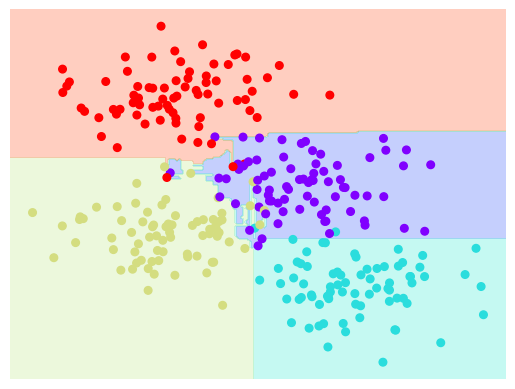

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

tree = DecisionTreeClassifier()
bag = BaggingClassifier(tree, n_estimators=100, max_samples=0.8,
                        random_state=1)

bag.fit(X, y)
visualize_classifier(bag, X, y)

In this example, randomness was introduced by training each estimator on a random subset containing 80% of the training data. In practice, however, decision trees are often randomized more effectively by adding randomness to the way splits are selected. This allows all training data to contribute to the model, while still ensuring that the individual trees remain sufficiently different from one another.

For example, when choosing the feature to split on at a given node, a randomized tree may consider only a subset of the available features instead of evaluating all of them.

In Scikit-Learn, this optimized ensemble of randomized decision trees is provided by the `RandomForestClassifier` estimator, which handles the randomization process automatically. The main parameter we need to set is the number of estimators, which corresponds to the number of trees in the forest. These trees can be trained efficiently, and even in parallel if desired:

/tmp/ipykernel_597/1795456885.py:20: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,


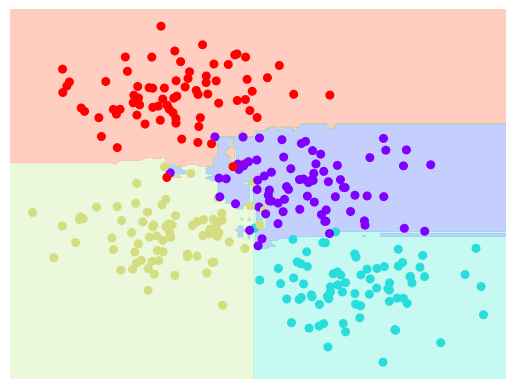

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=0)
visualize_classifier(model, X, y);

/tmp/ipykernel_597/1795456885.py:20: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,


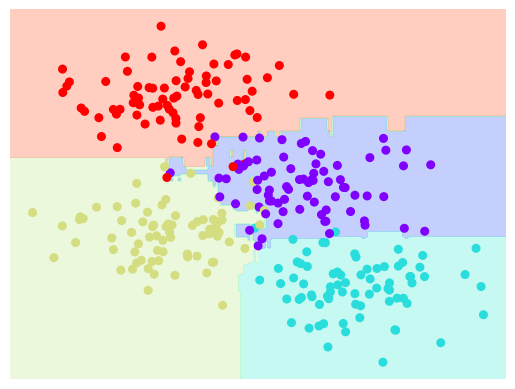

In [8]:
model = RandomForestClassifier(n_estimators=10, random_state=0)
visualize_classifier(model, X, y);

/tmp/ipykernel_597/1795456885.py:20: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,


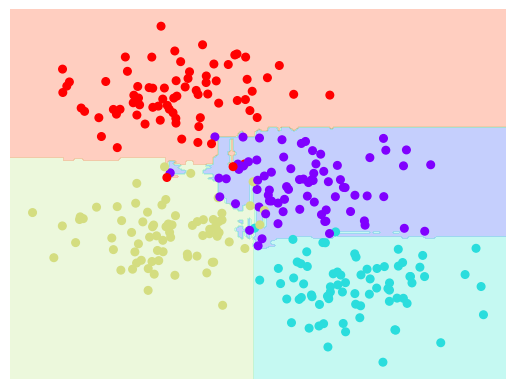

In [9]:
model = RandomForestClassifier(n_estimators=10000, random_state=0)
visualize_classifier(model, X, y);

**Question 5: Try increasing and decreasing the number of estimators in the examples above. What do you observe about the accuracy and execution time of the Random Forest method?**

Increasing $n\_estimators$ initially improves accuracy because aggregating more trees reduces the variance of the ensemble prediction, but the gains plateau quickly, beyond a certain number of trees, additional ones bring negligible improvement.
Execution time, however, grows roughly linearly with $n\_estimators$, since each tree is trained independently. This creates a clear tradeoff:

very few trees → unstable predictions

too many trees → wasted computation with no accuracy gain

In practice, a few hundred trees is usually a good balance.

**Question 6: Is pruning necessary when using Random Forests, as it often is with individual Decision Trees? Justify your answer.**

No, pruning is generally not necessary for Random Forests. A single Decision Tree needs pruning because it tends to overfit when grown to full depth. In a Random Forest, however, overfitting is controlled by two ensemble mechanisms: each tree is trained on a different bootstrap sample of the data, and at each split only a random subset of features is considered. This makes each tree overfit in a different way, so their individual errors are largely uncorrelated.
When the predictions are aggregated (majority voting for classification, averaging for regression), these less correlated errors cancel out, while the true patterns reinforce each other. In fact, pruning individual trees would reduce their diversity and hurt the ensemble's performance.

# Regression with Random Forests

Random Forests are not used only for classification tasks; they can also be applied to regression problems. For regression, Scikit-Learn provides the `RandomForestRegressor` estimator, which follows a syntax similar to the one used for classification.

Suppose we have the following dataset, generated by combining a fast oscillation with a slower one:

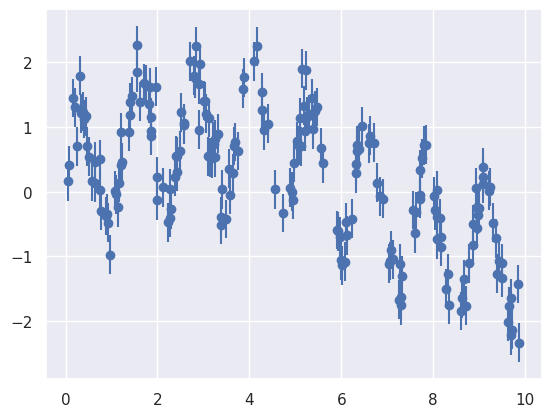

In [10]:
rng = np.random.RandomState(42)
x = 10 * rng.rand(200)

def model(x, sigma=0.3):
    fast_oscillation = np.sin(5 * x)
    slow_oscillation = np.sin(0.5 * x)
    noise = sigma * rng.randn(len(x))

    return slow_oscillation + fast_oscillation + noise

y = model(x)
plt.errorbar(x, y, 0.3, fmt='o');


Using regression based on Random Forests, we can fit a curve to the data as follows:

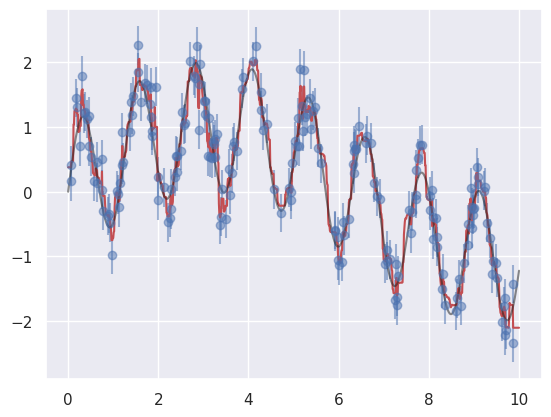

In [11]:
from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor(200)
forest.fit(x[:, None], y)

xfit = np.linspace(0, 10, 1000)
yfit = forest.predict(xfit[:, None])
ytrue = model(xfit, sigma=0)

plt.errorbar(x, y, 0.3, fmt='o', alpha=0.5)
plt.plot(xfit, yfit, '-r');
plt.plot(xfit, ytrue, '-k', alpha=0.5);

# Example: Random Forest for Digit Classification

We import the required libraries and the relevant handwritten digits dataset.

In [12]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

In [13]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

Visualizing some digits

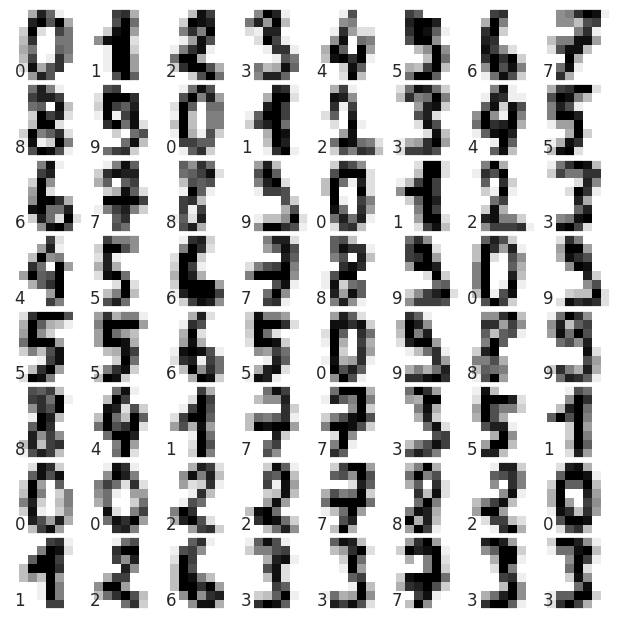

In [14]:
# set up the figure
fig = plt.figure(figsize=(6, 6))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

# plot the digits: each image is 8x8 pixels
for i in range(64):
    ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation='nearest')

    # label the image with the target value
    ax.text(0, 7, str(digits.target[i]))

We classify the digits using Random Forest.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

Xtrain, Xtest, ytrain, ytest = train_test_split(digits.data, digits.target,
                                                random_state=0)
model = RandomForestClassifier(n_estimators=1000)
model.fit(Xtrain, ytrain)
ypred = model.predict(Xtest)

In [16]:
from sklearn import metrics
print(metrics.classification_report(ypred, ytest))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        38
           1       0.98      0.95      0.97        44
           2       0.95      1.00      0.98        42
           3       0.98      0.98      0.98        45
           4       0.97      1.00      0.99        37
           5       0.98      0.96      0.97        49
           6       1.00      1.00      1.00        52
           7       1.00      0.96      0.98        50
           8       0.94      0.98      0.96        46
           9       0.98      0.98      0.98        47

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



Visualization of the errors using a [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix)

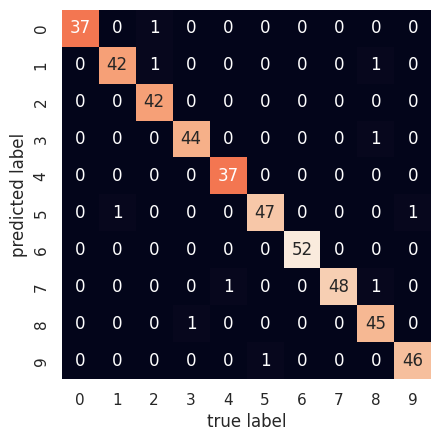

In [17]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(ytest, ypred)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('true label')
plt.ylabel('predicted label');

<ul>
<li><b>Question 7:</b> Explain why evaluation metrics such as precision, recall, and F1-score are useful in addition to accuracy.</li>
<li><b>Question 8:</b> What other methods are commonly used to evaluate machine learning models? Mention some of them and briefly explain their advantages.</li>
</ul>

**Question 7(Answer):**

Accuracy measures the overall percentage of correct predictions, but it can be misleading when the classes are imbalanced or when different types of errors have different importance. Precision measures how reliable the positive predictions are, since it shows how many predicted positives were actually positive. Recall measures how many of the actual positives the model successfully detected. The F1-score combines precision and recall using their harmonic mean, so it is useful when we want a balanced measure between false positives and false negatives. Therefore, precision, recall, and F1-score give a more complete evaluation than accuracy alone, especially in problems such as fraud detection, medical diagnosis, anomaly detection, or multi-class classification.

**Question 8(Answer):**

1. Train/Test Split

What: Reserve a portion of the data (e.g., 20%) as a test set never seen during training.
Advantage: Simplest way to detect overfitting; quick to implement.

2. K-Fold Cross-Validation

What: Split data into k folds; train k times, each using a different fold as the test set; average the results.
Advantage: More robust accuracy estimate that doesn't depend on a single lucky/unlucky split and uses all data for both training and testing; also reveals model variance.

3. Confusion Matrix

What: A table showing predicted vs. true labels for every class.
Advantage: Reveals which classes the model confuses with which others, far more diagnostic than a single accuracy number, especially for multi-class problems.

4. ROC Curve and AUC

What: Plot True Positive Rate vs. False Positive Rate across all possible classification thresholds.
Advantage: Threshold-independent, evaluates the model's ranking ability rather than a specific decision boundary. AUC = 1 means perfect, 0.5 means random.

5. Out-Of-Bag (OOB) Error — Specific To Random Forests

What: For each tree, the training observations not selected in its bootstrap sample form a built-in test set for that tree. Their errors are aggregated across the forest.
Advantage: Provides a validation estimate without needing a separate test set or cross-validation.